# Circular moments: the paper's diagnostic, novelty, and reproduction

A periodic chain makes ordinary position and variance ambiguous: a narrow packet crossing the boundary can appear split across opposite ends. The paper resolves this by mapping the measured magnetization to a quasi-probability and taking its first circular moment,

$$R(t)=\sum_n p_n(t)e^{i\theta_n}=e^{i\mu(t)-\sigma(t)^2/2}.$$

The angle records motion; the radius records spreading. Both come only from local Z-basis measurements.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd() / 'src'))

import numpy as np
import matplotlib.pyplot as plt
from swappy import REGIMES, simulate_ensemble
from swappy.published_data import load_published_static_data
from swappy.transport import fit_power_law, integrated_speed

SEED = 241114357

## 1. Read the complex plane

A stationary localized excitation leaves `R` near one point on the unit circle. Diffusion contracts it toward the origin. Coherent transport rotates it. The swappy regime does both, which is why neither spread nor drift alone is enough.

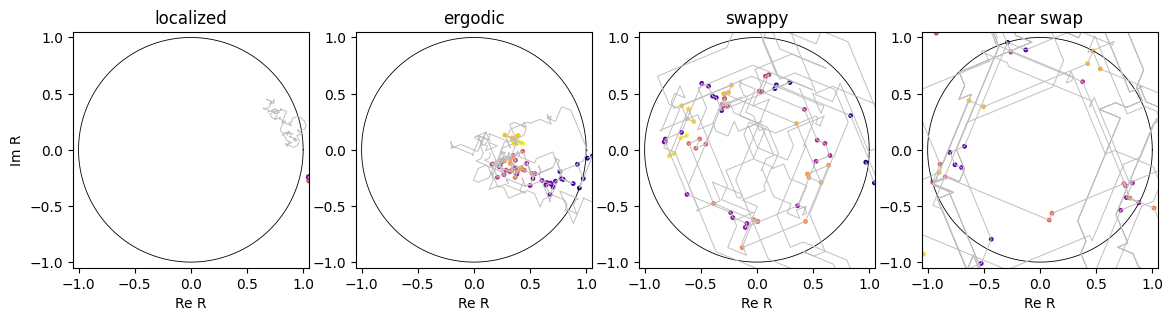

In [2]:
ensembles = {
    name: simulate_ensemble(8, J, cycles=8, realizations=4, seed=SEED + 100*i)
    for i, (name, J) in enumerate(REGIMES.items())
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
circle = np.linspace(0, 2*np.pi, 400)
for axis, (name, result) in zip(axes, ensembles.items()):
    axis.plot(np.cos(circle), np.sin(circle), color='black', lw=0.6)
    for trajectory in result.trajectories:
        R = trajectory.circular_mean
        axis.plot(R.real, R.imag, color='0.75', lw=0.7)
    R = result.trajectories[0].circular_mean
    axis.scatter(R.real, R.imag, c=result.times, cmap='plasma', s=6)
    axis.set_title(name.replace('_', ' '))
    axis.set_aspect('equal')
    axis.set(xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), xlabel='Re R')
axes[0].set_ylabel('Im R')
plt.show()

## 2. Three complementary observables

`sigma` measures spread when a wrapped-normal description is sensible. `nu` is the boundary-safe drift speed in sites per Floquet cycle. `p_max` measures the surviving peak even when the swappy profile is staggered and non-Gaussian.

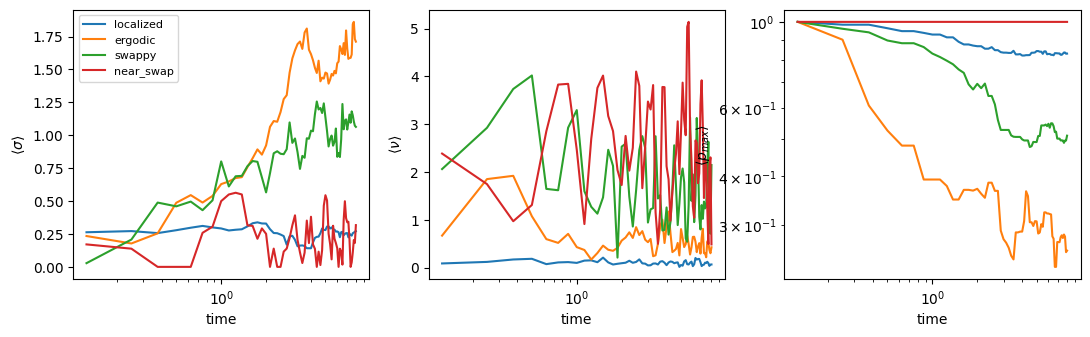

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for name, result in ensembles.items():
    axes[0].plot(result.times[1:], result.mean_spread[1:], label=name)
    axes[1].plot(result.times[1:], result.mean_speed[1:])
    axes[2].plot(result.times[1:], result.mean_peak[1:])
axes[0].set(xlabel='time', ylabel=r'$\langle\sigma\rangle$', xscale='log')
axes[1].set(xlabel='time', ylabel=r'$\langle\nu\rangle$', xscale='log')
axes[2].set(xlabel='time', ylabel=r'$\langle p_{max}\rangle$', xscale='log', yscale='log')
axes[0].legend(fontsize=8)
plt.show()

## 3. Replot the published static data correctly

The archived POLFED tables use an older Pauli-angle convention. The supported loader explicitly converts `J_paper = 4 J_stored` and divides eigenstate entropy by the finite-size Page value in the fixed-charge sector.

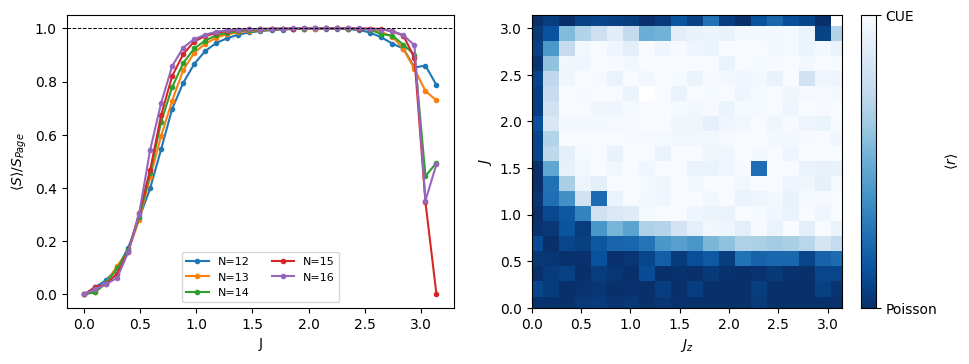

In [4]:
entropy, gaps = load_published_static_data()
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for N in sorted(entropy.N.unique()):
    data = entropy[entropy.N == N].sort_values('J_paper')
    axes[0].plot(data.J_paper, data.normalized_entanglement, 'o-', ms=3, label=f'N={N}')
axes[0].axhline(1, color='black', ls='--', lw=0.7)
axes[0].set(xlabel='J', ylabel=r'$\langle S\rangle/S_{Page}$')
axes[0].legend(ncol=2, fontsize=8)

gap_phase = gaps[gaps.N == 15]
grid = gap_phase.pivot(index='J_paper', columns='Jz_paper', values='gap_ratio_mean')
heatmap = axes[1].pcolormesh(grid.columns, grid.index, grid.values, shading='auto', cmap='Blues_r', vmin=0.3863, vmax=0.6027)
axes[1].set(xlabel=r'$J_z$', ylabel=r'$J$', xlim=(0, np.pi), ylim=(0, np.pi))
colorbar = fig.colorbar(heatmap, ax=axes[1], label=r'$\langle r\rangle$')
colorbar.set_ticks([0.3863, 0.6027], labels=['Poisson', 'CUE'])
plt.show()

## 4. A seeded finite-size phase scan

This scan is a mechanism check, not a replacement for the paper's `N=14...22` production scaling. It should already reveal low drift in the localized/ergodic region and a rapid rise toward the typical generalized-SWAP drift.

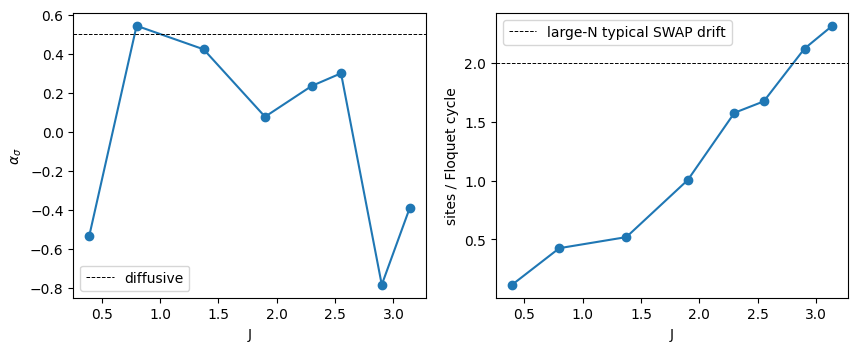

In [5]:
J_values = np.array([0.395, 0.8, 1.374, 1.9, 2.3, 2.551, 2.9, 3.138])
scan = [
    simulate_ensemble(8, J, cycles=8, realizations=4, seed=SEED + 1000 + i)
    for i, J in enumerate(J_values)
]
alpha_sigma = [
    fit_power_law(r.times, r.mean_spread, (1.0, 3.5))['exponent'] for r in scan
]
speeds = [integrated_speed(r) for r in scan]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
axes[0].plot(J_values, alpha_sigma, 'o-')
axes[0].axhline(0.5, color='black', ls='--', lw=0.7, label='diffusive')
axes[0].set(xlabel='J', ylabel=r'$\alpha_\sigma$')
axes[0].legend()
axes[1].plot(J_values, speeds, 'o-')
axes[1].axhline(2, color='black', ls='--', lw=0.7, label='large-N typical SWAP drift')
axes[1].set(xlabel='J', ylabel='sites / Floquet cycle')
axes[1].legend()
plt.show()

## What the paper adds

The novelty is not merely a fast point at exact SWAP. The evidence supports an extended, finite-time **prethermal dynamical regime**: it is absent from static chaos diagnostics, stable over a region of `(J, Jz)`, and its lifetime grows as the generalized-SWAP point is approached. Circular statistics make this behavior both visually legible and experimentally measurable.

To launch the full main-setting scan outside the notebook:

```bash
make paper
```

That profile uses `N=20`, 100 realizations, 10,000 cycles, and 33 `J` points, saving resumable data per point.